# 🧠 MobileNetV3 Small + SSD-Lite para ESP32-S3

**Objetivo**: Entrenar un modelo de detección de objetos ligero usando Transfer Learning con MobileNetV3 Small como backbone y cabezal SSD-Lite, optimizado para despliegue en ESP32-S3 (N16R8).

## Arquitectura

- **Backbone**: MobileNetV3 Small (minimalistic=True para compatibilidad TFLite)
- **Head**: SSD-Lite con convoluciones separables en profundidad
- **Clases**: 4 (door, footpath, obstacle, person)
- **Input**: 224×224×3 RGB

## Estrategia de Entrenamiento (2 Fases)

| Fase | Backbone | LR | Épocas | Objetivo |
|------|----------|----|---------| ---------|
| 1. Warm-up | 🔒 Congelado | 1e-3 | 15 | Entrenar solo el cabezal SSD-Lite |
| 2. Fine-tuning | 🔓 Últimas 30 capas | 1e-5 | 100 | Ajustar backbone + head con early stopping |

## Manejo de Desbalance

- **Focal Loss** (α=0.25, γ=2.0) para enfocar en ejemplos difíciles
- **Class Weights** calculados por frecuencia inversa

## 1. Setup y Configuración

In [1]:
# Imports y configuración inicial
import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Suprimir warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# TensorFlow
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

# Configurar memoria GPU (evitar OOM)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Memory growth habilitado para {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(f"⚠️ Error configurando GPU: {e}")

TensorFlow version: 2.16.2
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Memory growth habilitado para 1 GPU(s)


In [2]:
# Agregar paths al sistema
PROJECT_ROOT = Path.cwd().parent.parent  # TFM_UNIR
ING_MODELOS = PROJECT_ROOT / "02_ING_MODELOS"
ING_DATOS = PROJECT_ROOT / "01_ING_DATOS"

# Agregar módulos personalizados
sys.path.insert(0, str(ING_MODELOS))
sys.path.insert(0, str(ING_MODELOS / "src_mobilenet"))

print(f"📁 Project root: {PROJECT_ROOT}")
print(f"📁 ING_MODELOS: {ING_MODELOS}")
print(f"📁 ING_DATOS: {ING_DATOS}")

📁 Project root: /Users/admin/Documents/TFM_UNIR
📁 ING_MODELOS: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS
📁 ING_DATOS: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS


In [3]:
# Importar módulos personalizados de src_mobilenet
from src_mobilenet.utils_mobilenet_model import (
    build_mobilenetv3_ssd_lite,
    build_mobilenetv2_ssd_lite,
    print_model_summary,
)
from src_mobilenet.utils_mobilenet_data import (
    load_coco_annotations,
    compute_class_weights,
    generate_anchors,
    COCODataGenerator,
    compute_anchor_statistics,
)
from src_mobilenet.utils_mobilenet_losses import (
    focal_loss,
    binary_focal_loss,
    smooth_l1_loss,
    ssd_combined_loss,
)
from src_mobilenet.utils_mobilenet_train import (
    freeze_backbone,
    unfreeze_backbone_layers,
    create_callbacks,
    train_two_phase,
    save_training_history,
    plot_training_history,
    LearningRateLogger,
)
from src_mobilenet.utils_mobilenet_export import (
    export_tflite,
    export_tflite_int8,
    export_for_esp32,
    estimate_model_size,
    verify_tflite_model,
)

print("✅ Módulos de src_mobilenet importados correctamente")

✅ Módulos de src_mobilenet importados correctamente


## 🔬 Configuración del Experimento

Esta sección define los parámetros del experimento actual. Modifica estas variables para crear diferentes experimentos:

- **EXPERIMENT_NAME**: Identificador único del experimento
- **SELECTED_CLASSES**: Subconjunto de clases a entrenar (o None para todas)
- **AUGMENTATION_LEVEL**: "none", "light", "medium", "heavy"

In [ ]:
# ============================================
# 🔬 CONFIGURACIÓN DEL EXPERIMENTO
# ============================================
# Modifica estos valores para cada experimento diferente

# Nombre único del experimento
EXPERIMENT_NAME = "MBNTv3_ssdlite_v3"

# Descripción del experimento
EXPERIMENT_DESCRIPTION = "Baseline con clases 'obstacle' y 'footpath', augmentation heavy, 45 épocas totales"

# Clases a incluir (None = todas, o lista de nombres)
# Ejemplo: ["door", "person"] para entrenar solo 2 clases
# SELECTED_CLASSES = None  # Usar todas: door, footpath, obstacle, person
SELECTED_CLASSES = ["obstacle", "footpath"]  # Excluir person y door

# Nivel de augmentación: "none", "light", "medium", "heavy"
AUGMENTATION_LEVEL = "heavy"

# ============================================
# Importar gestión de experimentos
# ============================================
from src_mobilenet.utils_mobilenet_experiment import (
    ExperimentConfig,
    ExperimentResults,
    Experiment,
    save_experiment,
    create_default_config,
)
from src_mobilenet.utils_mobilenet_eval import (
    evaluate_model_full,
    compare_keras_vs_tflite,
    plot_confusion_matrix,
)
from src_mobilenet.utils_mobilenet_infer import (
    postprocess_detections,
    visualize_detections,
    visualize_predictions_nms,
    run_inference_keras,
    run_inference_tflite,
)

print(f"🔬 Experimento: {EXPERIMENT_NAME}")
print(f"📝 Descripción: {EXPERIMENT_DESCRIPTION}")
print(f"📋 Clases seleccionadas: {SELECTED_CLASSES or 'Todas (4 clases)'}")
print(f"🔄 Augmentación: {AUGMENTATION_LEVEL}")

🔬 Experimento: MBNTv3_ssdlite_v2
📝 Descripción: Baseline con clases 'obstacle' y 'footpath', augmentation heavy, 45 épocas totales
📋 Clases seleccionadas: ['obstacle', 'footpath']
🔄 Augmentación: heavy


In [ ]:
# ============================================
# CONFIGURACIÓN DE RUTAS Y PARÁMETROS
# ============================================

# --- Rutas del Dataset ---
TRAIN_IMG_DIR = ING_DATOS / "Dataset/train/augmented2_images"
TRAIN_JSON = ING_DATOS / "Dataset/train/augmented2_images/train_final2.json"

VAL_IMG_DIR = ING_DATOS / "Dataset/valid"
VAL_JSON = ING_DATOS / "Dataset/valid/val_final.json"

TEST_IMG_DIR = ING_DATOS / "Dataset/test"
TEST_JSON = ING_DATOS / "Dataset/test/test_final.json"

# --- Rutas de Salida ---
REPORTS_DIR = ING_MODELOS / "reports"
FIGURES_DIR = ING_MODELOS / "reports/figures" / EXPERIMENT_NAME 
MODELS_DIR = ING_MODELOS / "models"
CHECKPOINTS_DIR = ING_MODELOS / "models/checkpoints"
EXPORT_DIR = ING_MODELOS / "models/final_export"
LOGS_DIR = ING_MODELOS / "logs"
DATASETS_DIR = ING_MODELOS / "datasets/mobilenet"

# Crear directorios
for d in [REPORTS_DIR, FIGURES_DIR, MODELS_DIR, CHECKPOINTS_DIR, EXPORT_DIR, LOGS_DIR, DATASETS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- Parámetros del Modelo ---
IMG_SIZE = 224

# Clases: se actualizan después de cargar el dataset si SELECTED_CLASSES está definido
if SELECTED_CLASSES is not None:
    CLASS_NAMES = SELECTED_CLASSES
    NUM_CLASSES = len(SELECTED_CLASSES)
else:
    CLASS_NAMES = ["door", "footpath", "obstacle", "person"]  # Orden por category_id
    NUM_CLASSES = 4

print(f"   Clases ({NUM_CLASSES}): {CLASS_NAMES}")

# --- Parámetros de Anchors ---
FEATURE_MAP_SIZE = 7  # 224 / 32
ANCHOR_SCALES = [0.08, 0.2, 0.4, 0.6] # [0.03, 0.07, 0.12, 0.2, 0.35, 0.5] # [0.05, 0.1, 0.2, 0.35, 0.5]  # Antes: [0.1, 0.2, 0.4]
ANCHOR_RATIOS = [0.5, 1.0, 2.0]  # [0.33, 0.5, 1.0, 2.0, 3.0]  # Antes: [0.5, 1.0, 2.0]
NUM_ANCHORS_PER_CELL = len(ANCHOR_SCALES) * len(ANCHOR_RATIOS)  # 25 (antes 9)
IOU_THRESHOLD = 0.35 # 0.3  # Antes: 0.35

# --- Hiperparámetros de Entrenamiento ---
BATCH_SIZE = 16 # Antes 32

# Fase 1: Warm-up
PHASE1_EPOCHS = 30 # 20  # Antes 15
PHASE1_LR = 1e-3 # 5e-4    # Antes 1e-3

# Fase 2: Fine-tuning  
PHASE2_EPOCHS = 50 # 80 # Antes 100
PHASE2_LR = 5e-5 # 1e-4 #5e-5 # Antes 1e-5
NUM_LAYERS_TO_UNFREEZE = 40 # 60 # 50 # Antes 30

# Callbacks
PATIENCE_REDUCE_LR = 7 # 5 # 7 # Antes 5
PATIENCE_EARLY_STOP = 12 # 15 # 20 # Antes 15
REDUCE_LR_FACTOR = 0.5 # 0.3 # Antes 0.2

# Loss weights
CLS_WEIGHT = 1.0 # 2.0 # 1.5 # Antes 1.0 - Sube peso de clasificación
OBJ_WEIGHT = 2.5 # 1.0
BBOX_WEIGHT = 1.0 # 1.5 # Antes 2.0 - Reducir un poco bbox para no sobreajustar localización

# Focal Loss params
FOCAL_ALPHA = 0.25
FOCAL_GAMMA = 2.0 # 3.0 # 2.5 # Antes 2.0

# Umbral de puntuación para filtrar detecciones en evaluación/inferencia
SCORE_THRESHOLD = 0.3 # 0.4

# Número de canales en las características extraídas por el backbone
FEATURE_CHANNELS = 128

# Nombre del experimento (usar el definido en la sección de configuración)
MODEL_NAME = EXPERIMENT_NAME

print("✅ Configuración cargada")
print(f"   Dataset train: {TRAIN_IMG_DIR}")
print(f"   Modelo: {MODEL_NAME}")
print(f"   Anchors por celda: {NUM_ANCHORS_PER_CELL}")

   Clases (2): ['obstacle', 'footpath']
✅ Configuración cargada
   Dataset train: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/train/augmented2_images
   Modelo: MBNTv3_ssdlite_v2
   Anchors por celda: 30


## 2. Cargar y Analizar Dataset

In [6]:
# Cargar anotaciones COCO (con filtrado opcional de clases)
print("📂 Cargando dataset de entrenamiento...")
train_data, cat_id_to_name, cat_id_to_idx, CLASS_NAMES = load_coco_annotations(
    json_path=str(TRAIN_JSON),
    image_dir=str(TRAIN_IMG_DIR),
    allowed_classes=SELECTED_CLASSES,  # Filtra clases si está definido
)

# Actualizar NUM_CLASSES basado en el dataset cargado
NUM_CLASSES = len(CLASS_NAMES)
print(f"   Clases activas ({NUM_CLASSES}): {CLASS_NAMES}")

print("\n📂 Cargando dataset de validación...")
val_data, _, _, _ = load_coco_annotations(
    json_path=str(VAL_JSON),
    image_dir=str(VAL_IMG_DIR),
    allowed_classes=SELECTED_CLASSES,
)

print("\n📂 Cargando dataset de test...")
test_data, _, _, _ = load_coco_annotations(
    json_path=str(TEST_JSON),
    image_dir=str(TEST_IMG_DIR),
    allowed_classes=SELECTED_CLASSES,
)

print(f"\n📊 Resumen del Dataset:")
print(f"   Train: {len(train_data)} imágenes")
print(f"   Val:   {len(val_data)} imágenes")
print(f"   Test:  {len(test_data)} imágenes")

📂 Cargando dataset de entrenamiento...
📋 Filtering to 2 classes: ['footpath', 'obstacle']
   Removed 376 images with no annotations for selected classes
✅ Loaded 995 images with annotations
   Categories: {5: 'footpath', 6: 'obstacle'}
   Class mapping: {5: 0, 6: 1}
   Class names (ordered): ['footpath', 'obstacle']
   Clases activas (2): ['footpath', 'obstacle']

📂 Cargando dataset de validación...
📋 Filtering to 2 classes: ['footpath', 'obstacle']
   Removed 17 images with no annotations for selected classes
✅ Loaded 68 images with annotations
   Categories: {5: 'footpath', 6: 'obstacle'}
   Class mapping: {5: 0, 6: 1}
   Class names (ordered): ['footpath', 'obstacle']

📂 Cargando dataset de test...
📋 Filtering to 2 classes: ['footpath', 'obstacle']
   Removed 13 images with no annotations for selected classes
✅ Loaded 71 images with annotations
   Categories: {5: 'footpath', 6: 'obstacle'}
   Class mapping: {5: 0, 6: 1}
   Class names (ordered): ['footpath', 'obstacle']

📊 Resumen d

In [7]:
# Calcular pesos de clase para manejar desbalance
class_weights = compute_class_weights(train_data, NUM_CLASSES, method="inverse_freq")

# Convertir a tensor para la loss function
class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)
print(f"\n⚖️ Class weights tensor: {class_weights}")


📊 Class distribution and weights (inverse_freq):
   Class 0:   784 samples, weight=1.551
   Class 1:  1648 samples, weight=0.738
   Total: 2432 samples

⚖️ Class weights tensor: [1.5510204 0.7378641]


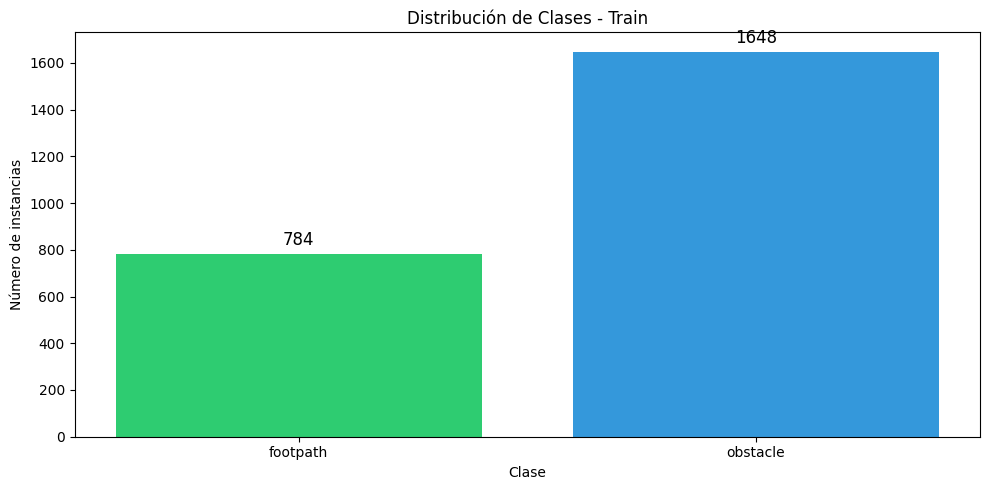

In [8]:
# Visualizar distribución de clases
from collections import Counter

def plot_class_distribution(data_list, title="Class Distribution"):
    """Visualizar distribución de clases."""
    class_counts = Counter()
    for img in data_list:
        for cls in img["classes"]:
            class_counts[cls] += 1
    
    classes = list(range(NUM_CLASSES))
    counts = [class_counts.get(c, 0) for c in classes]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(CLASS_NAMES, counts, color=['#2ecc71', '#3498db', '#e74c3c', '#9b59b6'])
    ax.set_xlabel('Clase')
    ax.set_ylabel('Número de instancias')
    ax.set_title(title)
    
    # Agregar etiquetas en las barras
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax.annotate(f'{count}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=12)
    
    plt.tight_layout()
    return fig

fig = plot_class_distribution(train_data, "Distribución de Clases - Train")
fig.savefig(FIGURES_DIR /   "mobilenet_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## 3. Generar Anchors y Data Generators

In [9]:
# Generar anchors para SSD
anchors = generate_anchors(
    feature_map_size=FEATURE_MAP_SIZE,
    scales=ANCHOR_SCALES,
    aspect_ratios=ANCHOR_RATIOS,
)

print(f"📦 Anchors generados: {anchors.shape}")
print(f"   Feature map: {FEATURE_MAP_SIZE}×{FEATURE_MAP_SIZE}")
print(f"   Anchors por celda: {NUM_ANCHORS_PER_CELL}")
print(f"   Total anchors: {len(anchors)}")

# Estadísticas de los anchors
print(f"\n   Tamaños de anchors (w×h):")
for scale in ANCHOR_SCALES:
    for ratio in ANCHOR_RATIOS:
        w = scale * np.sqrt(ratio)
        h = scale / np.sqrt(ratio)
        print(f"      scale={scale}, ratio={ratio:.1f} → w={w:.3f}, h={h:.3f}")

📦 Anchors generados: (1470, 4)
   Feature map: 7×7
   Anchors por celda: 30
   Total anchors: 1470

   Tamaños de anchors (w×h):
      scale=0.03, ratio=0.3 → w=0.017, h=0.052
      scale=0.03, ratio=0.5 → w=0.021, h=0.042
      scale=0.03, ratio=1.0 → w=0.030, h=0.030
      scale=0.03, ratio=2.0 → w=0.042, h=0.021
      scale=0.03, ratio=3.0 → w=0.052, h=0.017
      scale=0.07, ratio=0.3 → w=0.040, h=0.122
      scale=0.07, ratio=0.5 → w=0.049, h=0.099
      scale=0.07, ratio=1.0 → w=0.070, h=0.070
      scale=0.07, ratio=2.0 → w=0.099, h=0.049
      scale=0.07, ratio=3.0 → w=0.121, h=0.040
      scale=0.12, ratio=0.3 → w=0.069, h=0.209
      scale=0.12, ratio=0.5 → w=0.085, h=0.170
      scale=0.12, ratio=1.0 → w=0.120, h=0.120
      scale=0.12, ratio=2.0 → w=0.170, h=0.085
      scale=0.12, ratio=3.0 → w=0.208, h=0.069
      scale=0.2, ratio=0.3 → w=0.115, h=0.348
      scale=0.2, ratio=0.5 → w=0.141, h=0.283
      scale=0.2, ratio=1.0 → w=0.200, h=0.200
      scale=0.2, ratio=2.0 →

In [10]:
# Verificar matching de anchors con el dataset
anchor_stats = compute_anchor_statistics(train_data, anchors, iou_threshold=IOU_THRESHOLD)


📊 Anchor Matching Statistics:
   Total GT boxes: 2432
   Matched GT boxes (IoU≥0.35): 2160 (88.8%)
   Avg max IoU per GT: 0.560
   Min max IoU: 0.093
   Avg positive anchors/image: 45.3


In [11]:
# Crear generadores de datos
print("🔧 Creando generadores de datos...")
print(f"   Nivel de augmentación: {AUGMENTATION_LEVEL}")

train_gen = COCODataGenerator(
    images_data=train_data,
    anchors=anchors,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    iou_threshold=IOU_THRESHOLD,
    augmentation_level=AUGMENTATION_LEVEL,  # Usar nivel configurado
    shuffle=True,
)

val_gen = COCODataGenerator(
    images_data=val_data,
    anchors=anchors,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    iou_threshold=IOU_THRESHOLD,
    augmentation_level="none",  # Sin augmentación para validación
    shuffle=False,
)

test_gen = COCODataGenerator(
    images_data=test_data,
    anchors=anchors,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    iou_threshold=IOU_THRESHOLD,
    augmentation_level="none",  # Sin augmentación para test
    shuffle=False,
)

print(f"✅ Generadores creados:")
print(f"   Train: {len(train_gen)} batches × {BATCH_SIZE} = ~{len(train_gen)*BATCH_SIZE} samples")
print(f"   Val:   {len(val_gen)} batches")
print(f"   Test:  {len(test_gen)} batches")

🔧 Creando generadores de datos...
   Nivel de augmentación: heavy
📊 DataGenerator: 995 images, augmentation=heavy
📊 DataGenerator: 68 images, augmentation=none
📊 DataGenerator: 71 images, augmentation=none
✅ Generadores creados:
   Train: 63 batches × 16 = ~1008 samples
   Val:   5 batches
   Test:  5 batches


In [12]:
# Verificar un batch
sample_batch_x, sample_batch_y = train_gen[0]

print(f"📊 Verificación de batch:")
print(f"   X shape: {sample_batch_x.shape}")
print(f"   Y objectness shape: {sample_batch_y['objectness'].shape}")
print(f"   Y class_out shape: {sample_batch_y['class_out'].shape}")
print(f"   Y bbox_out shape: {sample_batch_y['bbox_out'].shape}")

# Estadísticas de positivos
positives_per_sample = sample_batch_y['objectness'].sum(axis=(1, 2))
print(f"\n   Positivos por imagen: min={positives_per_sample.min():.0f}, max={positives_per_sample.max():.0f}, mean={positives_per_sample.mean():.1f}")

📊 Verificación de batch:
   X shape: (16, 224, 224, 3)
   Y objectness shape: (16, 1470, 1)
   Y class_out shape: (16, 1470, 2)
   Y bbox_out shape: (16, 1470, 4)

   Positivos por imagen: min=1, max=96, mean=37.5


## 4. Construir Modelo MobileNetV3 + SSD-Lite

In [ ]:
# Construir modelo MobileNetV3 Small + SSD-Lite
# Nota: minimalistic=True usa ReLU en lugar de hard-swish (mejor para ESP32-S3)

model = build_mobilenetv3_ssd_lite(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES,
    num_anchors_per_cell=NUM_ANCHORS_PER_CELL,
    alpha=1.0,              # Width multiplier
    minimalistic=True,      # ReLU instead of hard-swish (ESP32 compatible)
    feature_channels=FEATURE_CHANNELS,   # SSD head channels
    use_batchnorm=True,
    dropout_rate= 0.3,  # 0.2,
    model_name=MODEL_NAME,
)

print_model_summary(model)


Model: MBNTv3_ssdlite_v2
Total params: 568,378
Trainable params: 554,346
Non-trainable params: 14,032
Estimated size (float32): 2.17 MB
Estimated size (int8): 0.54 MB



In [14]:
# Alternativa: MobileNetV2 (probado en ESP32-S3, más ligero)
# Descomentar para usar MobileNetV2 en lugar de MobileNetV3

# model = build_mobilenetv2_ssd_lite(
#     input_shape=(IMG_SIZE, IMG_SIZE, 3),
#     num_classes=NUM_CLASSES,
#     num_anchors_per_cell=NUM_ANCHORS_PER_CELL,
#     alpha=0.35,  # Más pequeño para ESP32-S3 (~250KB)
#     feature_channels=FEATURE_CHANNELS,
#     use_batchnorm=True,
#     dropout_rate=0.2,
#     model_name="mobilenetv2_ssdlite_v1",
# )

In [15]:
# Visualizar arquitectura del modelo
model.summary(show_trainable=True, expand_nested=False)

Model: "MBNTv3_ssdlite_v2"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer       │ (None, 224,     │         0 │ -              │   -   │
│ (InputLayer)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ conv (Conv2D)     │ (None, 112,     │       432 │ input_layer[0… │   Y   │
│                   │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ conv_bn           │ (None, 112,     │        64 │ conv[0][0]     │   Y   │
│ (BatchNormalizat… │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ re_lu (ReLU)      │ (None, 112,     │         0 │ conv_bn[0][0]  │   -   │
│                   │ 112, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 113,     │         0 │ re_lu[0][0]    │   -   │
│ (ZeroPadding2D)   │ 113, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 56, 56,  │       144 │ expanded_conv… │   Y   │
│ (DepthwiseConv2D) │ 16)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_de… │ (None, 56, 56,  │        64 │ expanded_conv… │   Y   │
│ (BatchNormalizat… │ 16)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ re_lu_1 (ReLU)    │ (None, 56, 56,  │         0 │ expanded_conv… │   -   │
│                   │ 16)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 56, 56,  │       256 │ re_lu_1[0][0]  │   Y   │
│ (Conv2D)          │ 16)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_pr… │ (None, 56, 56,  │        64 │ expanded_conv… │   Y   │
│ (BatchNormalizat… │ 16)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_1_… │ (None, 56, 56,  │     1,152 │ expanded_conv… │   Y   │
│ (Conv2D)          │ 72)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_1_… │ (None, 56, 56,  │       288 │ expanded_conv… │   Y   │
│ (BatchNormalizat… │ 72)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ re_lu_2 (ReLU)    │ (None, 56, 56,  │         0 │ expanded_conv… │   -   │
│                   │ 72)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_1_… │ (None, 57, 57,  │         0 │ re_lu_2[0][0]  │   -   │
│ (ZeroPadding2D)   │ 72)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_1_… │ (None, 28, 28,  │       648 │ expanded_conv… │   Y   │
│ (DepthwiseConv2D) │ 72)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ expanded_conv_1_… │ (None, 28, 28,  │       288 │ expanded_conv… │   Y   │
│ (BatchNormalizat… │ 72)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ re_lu_3 (ReLU)    │ (None, 28, 28,  │         0 │ expanded_conv… │   - 

 Total params: 568,378 (2.17 MB)

 Trainable params: 554,346 (2.11 MB)

 Non-trainable params: 14,032 (54.81 KB)

In [16]:
# Estimar tamaño del modelo para ESP32-S3
model_sizes = estimate_model_size(model)


📊 Model Size Estimates:
   Total parameters: 568,378
   Float32: 2220.2 KB (2.17 MB)
   Float16: 1110.1 KB (1.08 MB)
   INT8:    555.1 KB (0.54 MB)
   ✅ INT8 model fits ESP32-S3 flash limit (1024 KB)


## 5. Configurar Losses y Métricas

In [17]:
# Configurar funciones de pérdida con Focal Loss
# Focal Loss es clave para manejar el desbalance de clases en detección de objetos

loss_config = ssd_combined_loss(
    cls_weight=CLS_WEIGHT,
    obj_weight=OBJ_WEIGHT,
    bbox_weight=BBOX_WEIGHT,
    focal_alpha=FOCAL_ALPHA,
    focal_gamma=FOCAL_GAMMA,
    smooth_l1_delta=1.0,
    class_weights=class_weights_tensor,  # Pesos de clase calculados
    use_giou=False,  # Smooth L1 por defecto, cambiar a True para GIoU
)

losses = loss_config["losses"]
loss_weights = loss_config["weights"]

print("📉 Funciones de pérdida configuradas:")
print(f"   Objectness: Binary Focal Loss (α={FOCAL_ALPHA}, γ={FOCAL_GAMMA}) × {OBJ_WEIGHT}")
print(f"   Classification: Focal Loss (α={FOCAL_ALPHA}, γ={FOCAL_GAMMA}) × {CLS_WEIGHT}")
print(f"   Bounding Box: Smooth L1 Loss × {BBOX_WEIGHT}")
print(f"   Class weights: {class_weights}")

📉 Funciones de pérdida configuradas:
   Objectness: Binary Focal Loss (α=0.25, γ=3.0) × 1.0
   Classification: Focal Loss (α=0.25, γ=3.0) × 2.0
   Bounding Box: Smooth L1 Loss × 1.0
   Class weights: [1.5510204 0.7378641]


## 6. Entrenamiento Fase 1: Warm-up (Backbone Congelado)

En esta fase solo entrenamos el cabezal SSD-Lite. El backbone MobileNetV3 permanece congelado con los pesos de ImageNet.

In [18]:
# FASE 1: Congelar backbone, entrenar solo el cabezal SSD-Lite
print("\n" + "="*70)
print("🔒 FASE 1: WARM-UP - Backbone Congelado")
print("="*70)

# Congelar todas las capas del backbone
freeze_backbone(model)

# Compilar modelo para Fase 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=PHASE1_LR),
    loss=losses,
    loss_weights=loss_weights,
    metrics={
        "objectness": ["binary_accuracy"],
        "class_out": ["categorical_accuracy"],
    }
)

print(f"\n📋 Configuración Fase 1:")
print(f"   Learning Rate: {PHASE1_LR}")
print(f"   Épocas: {PHASE1_EPOCHS}")
print(f"   Batch Size: {BATCH_SIZE}")


🔒 FASE 1: WARM-UP - Backbone Congelado
🔒 Frozen 103 backbone layers
   Trainable params: 125,458 / 568,378 (22.1%)

📋 Configuración Fase 1:
   Learning Rate: 0.0005
   Épocas: 20
   Batch Size: 16


In [19]:
# Callbacks para Fase 1
phase1_callbacks = create_callbacks(
    checkpoint_dir=str(CHECKPOINTS_DIR),
    log_dir=str(LOGS_DIR ),
    model_name=f"{MODEL_NAME}_phase1",
    monitor="val_loss",
    patience_reduce_lr=PATIENCE_REDUCE_LR,
    patience_early_stop=PHASE1_EPOCHS,  # Sin early stopping en fase 1
    reduce_lr_factor=REDUCE_LR_FACTOR,
)

# Agregar logger de learning rate
lr_logger = LearningRateLogger()
phase1_callbacks.append(lr_logger)

📋 Created 5 callbacks:
   Checkpoint: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/MBNTv3_ssdlite_v2_phase1_best.keras
   Logs: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/MBNTv3_ssdlite_v2_phase1_history.csv
   Monitor: val_loss
   ReduceLR patience: 5, factor: 0.5
   EarlyStopping patience: 20


In [20]:
# Entrenar Fase 1
print("\n🚀 Iniciando entrenamiento Fase 1...")

history_phase1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=PHASE1_EPOCHS,
    callbacks=phase1_callbacks,
    verbose=1,
)

print("\n✅ Fase 1 completada")


🚀 Iniciando entrenamiento Fase 1...
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - bbox_out_loss: 0.1255 - class_out_categorical_accuracy: 0.4715 - class_out_loss: 0.1654 - loss: 0.5520 - objectness_binary_accuracy: 0.6554 - objectness_loss: 0.0953
Epoch 1: val_loss improved from None to 0.32534, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/MBNTv3_ssdlite_v2_phase1_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 189ms/step - bbox_out_loss: 0.1049 - class_out_categorical_accuracy: 0.4252 - class_out_loss: 0.1175 - loss: 0.4034 - objectness_binary_accuracy: 0.7630 - objectness_loss: 0.0621 - val_bbox_out_loss: 0.0759 - val_class_out_categorical_accuracy: 0.4378 - val_class_out_loss: 0.1101 - val_loss: 0.3253 - val_objectness_binary_accuracy: 0.9418 - val_objectness_loss: 0.0343 - learning_rate: 5.0000e-04 - lr: 5.0000e-04
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - bbox_out_loss: 0.0744 - class_out_categorical_accuracy: 0.3210 - class_out_l

💾 Saved training history to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/MBNTv3_ssdlite_v2_phase1_history.csv
📊 Saved training plot to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/MBNTv3_ssdlite_v2/MBNTv3_ssdlite_v2_phase1_curves.png


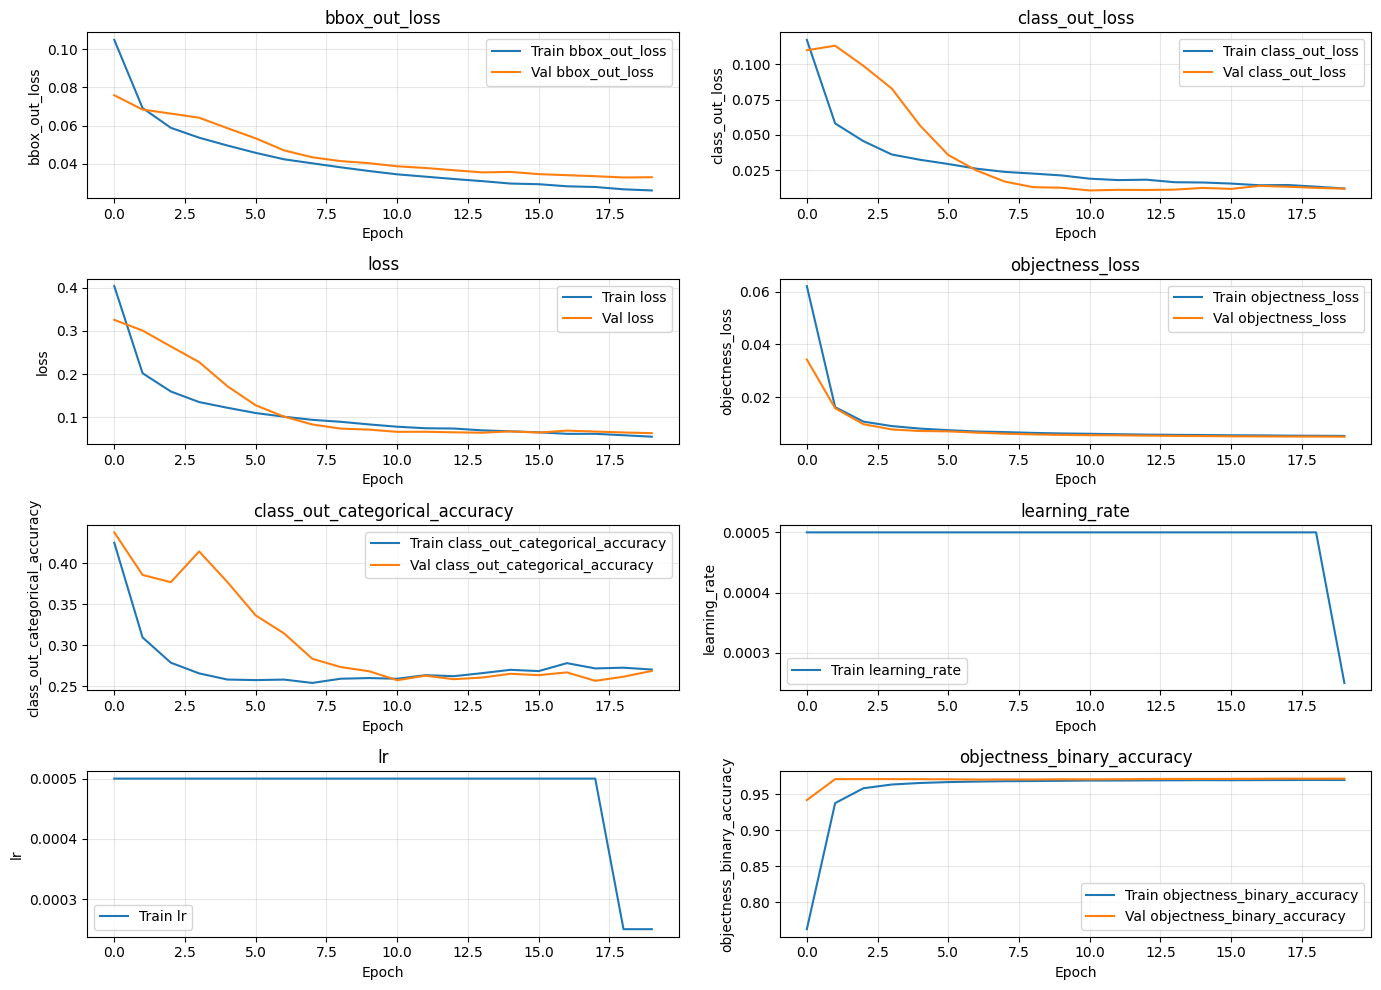

In [ ]:
# Guardar historial Fase 1
df_phase1 = save_training_history(
    history_phase1, 
    str(LOGS_DIR  / f"{MODEL_NAME}_phase1_history.csv")
)

# Visualizar progreso Fase 1
plot_training_history(
    history_phase1, 
    output_path=str(FIGURES_DIR / f"{MODEL_NAME}_phase1_curves.png"), 
    title=f"Fase 1: Warm-up - {MODEL_NAME}"
    )

## 7. Entrenamiento Fase 2: Fine-Tuning (Backbone Parcialmente Descongelado)

Descongelamos las últimas capas del backbone MobileNetV3 para que aprenda características específicas de nuestro dataset. **Learning rate muy bajo** para no destruir los pesos pre-entrenados.

In [22]:
# FASE 2: Descongelar últimas capas del backbone
print("\n" + "="*70)
print("🔓 FASE 2: FINE-TUNING - Backbone Parcialmente Descongelado")
print("="*70)

# Descongelar últimas N capas
unfreeze_backbone_layers(model, num_layers_to_unfreeze=NUM_LAYERS_TO_UNFREEZE)

# Recompilar con LR muy bajo (CRÍTICO)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=PHASE2_LR),
    loss=losses,
    loss_weights=loss_weights,
    metrics={
        "objectness": ["binary_accuracy"],
        "class_out": ["categorical_accuracy"],
    }
)

print(f"\n📋 Configuración Fase 2:")
print(f"   Learning Rate: {PHASE2_LR} (muy bajo para no destruir pesos)")
print(f"   Épocas máximas: {PHASE2_EPOCHS}")
print(f"   Early Stopping patience: {PATIENCE_EARLY_STOP}")
print(f"   ReduceLR patience: {PATIENCE_REDUCE_LR}")


🔓 FASE 2: FINE-TUNING - Backbone Parcialmente Descongelado
🔓 Unfroze last 60 layers
   Trainable params: 472,738 / 568,378 (83.2%)

📋 Configuración Fase 2:
   Learning Rate: 0.0001 (muy bajo para no destruir pesos)
   Épocas máximas: 80
   Early Stopping patience: 15
   ReduceLR patience: 5


In [23]:
# Callbacks para Fase 2 (con Early Stopping activo)
phase2_callbacks = create_callbacks(
    checkpoint_dir=str(CHECKPOINTS_DIR),
    log_dir=str(LOGS_DIR),
    model_name=f"{MODEL_NAME}_phase2",
    monitor="val_loss",
    patience_reduce_lr=PATIENCE_REDUCE_LR,
    patience_early_stop=PATIENCE_EARLY_STOP,
    reduce_lr_factor=REDUCE_LR_FACTOR,
)

# Agregar logger de learning rate
lr_logger_2 = LearningRateLogger()
phase2_callbacks.append(lr_logger_2)

📋 Created 5 callbacks:
   Checkpoint: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/MBNTv3_ssdlite_v2_phase2_best.keras
   Logs: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/MBNTv3_ssdlite_v2_phase2_history.csv
   Monitor: val_loss
   ReduceLR patience: 5, factor: 0.5
   EarlyStopping patience: 15


In [24]:
# Entrenar Fase 2
print("\n🚀 Iniciando entrenamiento Fase 2 (Fine-tuning)...")
print("   Esto puede tomar tiempo. Early stopping detendrá si no mejora.")

history_phase2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=PHASE2_EPOCHS,
    callbacks=phase2_callbacks,
    verbose=1,
)

print("\n✅ Fase 2 completada")


🚀 Iniciando entrenamiento Fase 2 (Fine-tuning)...
   Esto puede tomar tiempo. Early stopping detendrá si no mejora.
Epoch 1/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - bbox_out_loss: 0.0296 - class_out_categorical_accuracy: 0.2693 - class_out_loss: 0.0216 - loss: 0.0775 - objectness_binary_accuracy: 0.9692 - objectness_loss: 0.0056
Epoch 1: val_loss improved from None to 0.05894, saving model to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/MBNTv3_ssdlite_v2_phase2_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 43s 428ms/step - bbox_out_loss: 0.0297 - class_out_categorical_accuracy: 0.2691 - class_out_loss: 0.0212 - loss: 0.0768 - objectness_binary_accuracy: 0.9695 - objectness_loss: 0.0055 - val_bbox_out_loss: 0.0310 - val_class_out_categorical_accuracy: 0.2746 - val_class_out_loss: 0.0107 - val_loss: 0.0589 - val_objectness_binary_accuracy: 0.9716 - val_objectness_loss: 0.0048 - learning_rate: 1.0000e-04 - lr: 1.0000e-04
Epoch 2/80
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/st

💾 Saved training history to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/MBNTv3_ssdlite_v2_phase2_history.csv
📊 Saved training plot to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/MBNTv3_ssdlite_v2/MBNTv3_ssdlite_v2_phase2_curves.png


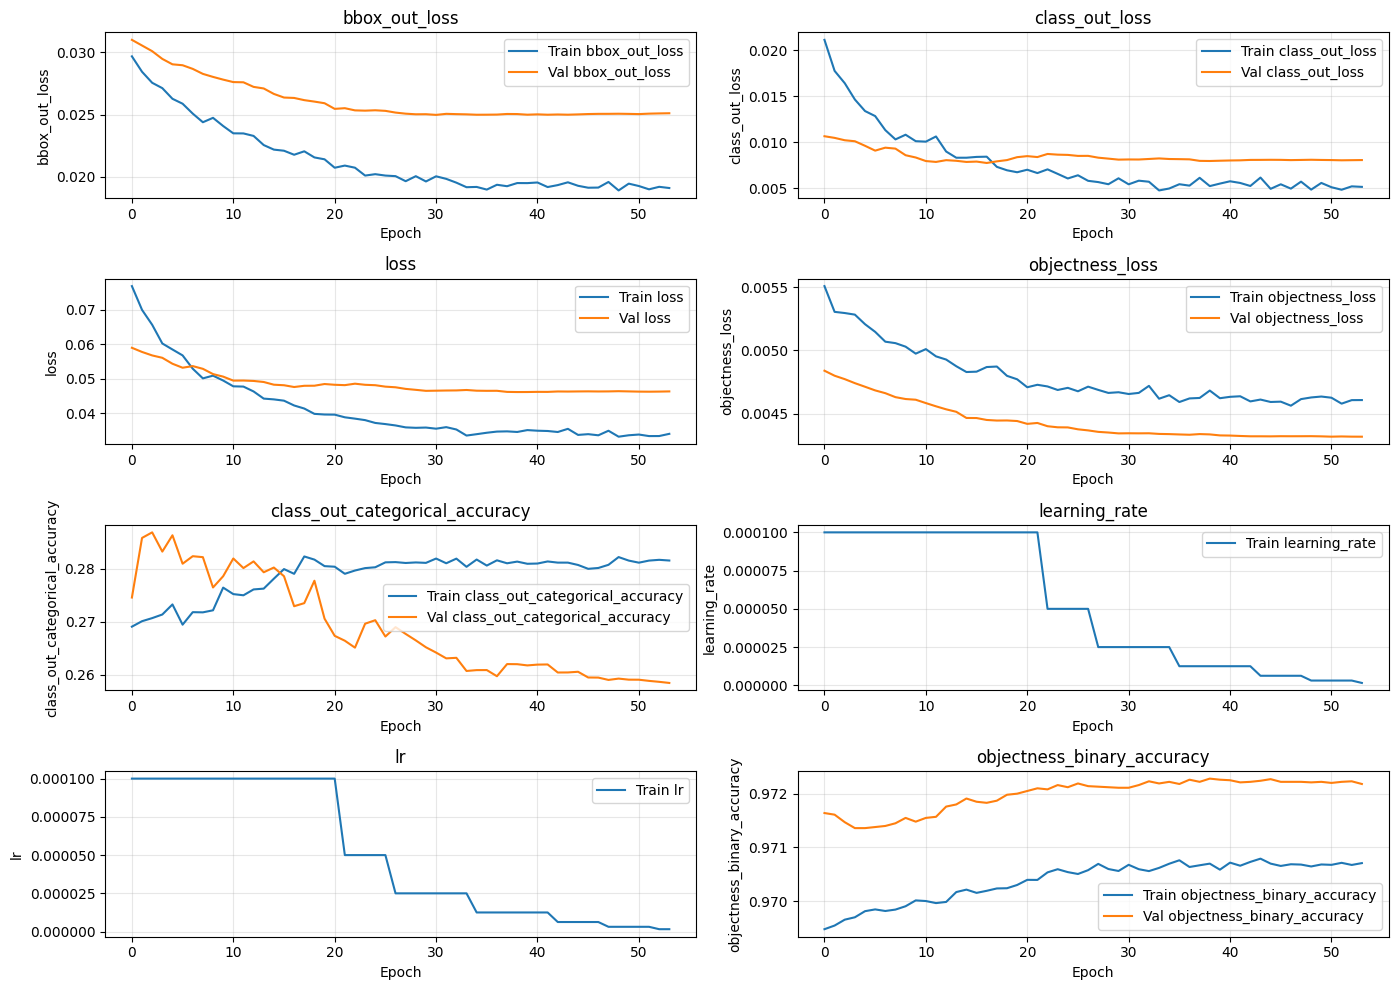

In [ ]:
# Guardar historial Fase 2
df_phase2 = save_training_history(
    history_phase2,
    str(LOGS_DIR / f"{MODEL_NAME}_phase2_history.csv")
)

# Visualizar progreso Fase 2
plot_training_history(
    history_phase2, 
    output_path=str(FIGURES_DIR   / f"{MODEL_NAME}_phase2_curves.png"),
    title=f"Fase 2: Fine Tuning - {MODEL_NAME}"
    )

## 8. Evaluación del Modelo

In [26]:
# Cargar mejor modelo guardado
best_model_path = CHECKPOINTS_DIR   / f"{MODEL_NAME}_phase2_best.keras"

if best_model_path.exists():
    print(f"📂 Cargando mejor modelo desde: {best_model_path}")
    model = tf.keras.models.load_model(
        best_model_path,
        custom_objects={
            "loss_fn": binary_focal_loss(FOCAL_ALPHA, FOCAL_GAMMA),
        },
        compile=False
    )
    # Recompilar
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=PHASE2_LR),
        loss=losses,
        loss_weights=loss_weights,
        metrics={
            "objectness": ["binary_accuracy"],
            "class_out": ["categorical_accuracy"],
        }
    )
    print("✅ Mejor modelo cargado")
else:
    print("⚠️ No se encontró checkpoint, usando modelo actual")

📂 Cargando mejor modelo desde: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/MBNTv3_ssdlite_v2_phase2_best.keras
✅ Mejor modelo cargado


In [27]:
# Evaluar en conjunto de validación
print("\n📊 Evaluación en conjunto de VALIDACIÓN:")
val_results = model.evaluate(val_gen, verbose=1)

print("\n📊 Evaluación en conjunto de TEST:")
test_results = model.evaluate(test_gen, verbose=1)

# Mostrar métricas
metric_names = model.metrics_names
print(f"\n{'='*50}")
print("RESUMEN DE MÉTRICAS")
print(f"{'='*50}")
print(f"{'Métrica':<35} {'Val':>10} {'Test':>10}")
print(f"{'-'*50}")
for name, val, test in zip(metric_names, val_results, test_results):
    print(f"{name:<35} {val:>10.4f} {test:>10.4f}")


📊 Evaluación en conjunto de VALIDACIÓN:
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 298ms/step - bbox_out_loss: 0.0250 - class_out_categorical_accuracy: 0.2620 - class_out_loss: 0.0080 - loss: 0.0461 - objectness_binary_accuracy: 0.9723 - objectness_loss: 0.0043

📊 Evaluación en conjunto de TEST:
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 346ms/step - bbox_out_loss: 0.0197 - class_out_categorical_accuracy: 0.3030 - class_out_loss: 0.0293 - loss: 0.0854 - objectness_binary_accuracy: 0.9720 - objectness_loss: 0.0041

RESUMEN DE MÉTRICAS
Métrica                                    Val       Test
--------------------------------------------------
loss                                    0.0461     0.0854
compile_metrics                         0.0043     0.0041
objectness_loss                         0.0080     0.0293
class_out_loss                          0.0250     0.0197
bbox_out_loss                           0.2620     0.3030


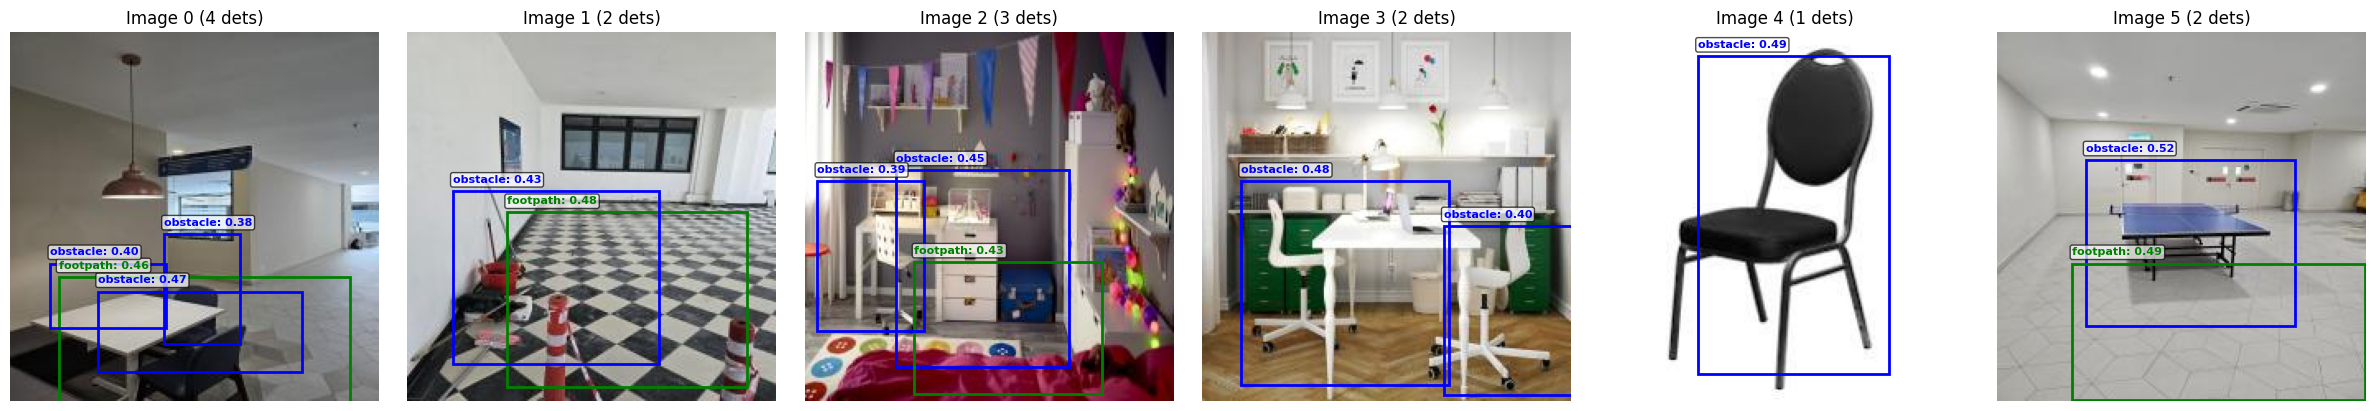

✅ Predicciones visualizadas con NMS aplicado


In [ ]:
# Visualizar predicciones en imágenes aleatorias de test (CON NMS)
# La función visualize_predictions_nms está modularizada en src_mobilenet/utils_mobilenet_infer.py

fig = visualize_predictions_nms(
    model=model,
    images_data=test_data,
    anchors=anchors,
    class_names=CLASS_NAMES,
    img_size=IMG_SIZE,
    num_samples=8,
    score_threshold=SCORE_THRESHOLD,
    nms_iou_threshold=0.2,
    random_seed=None,  # None = selección aleatoria cada vez, o fijar un número para reproducibilidad
    save_path=str(FIGURES_DIR / f"{MODEL_NAME}_predictions_nms.png"),
    title=f"Predicciones con NMS - {MODEL_NAME}",
    max_cols=4
)
plt.show()
print("✅ Predicciones visualizadas con NMS aplicado (imágenes aleatorias)")

## 9. Exportar a TFLite para ESP32-S3

In [29]:
# Guardar modelo Keras final
model_keras_path = EXPORT_DIR   / f"{MODEL_NAME}_final.keras"
model.save(model_keras_path)
print(f"💾 Modelo Keras guardado: {model_keras_path}")

💾 Modelo Keras guardado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/final_export/MBNTv3_ssdlite_v2_final.keras


In [30]:
# ============================================
# EXPORTACIÓN TFLite PARA ESP32-S3
# ============================================
# 
# IMPORTANTE: La conversión TFLite puede fallar en el notebook por problemas de memoria.
# Se recomienda ejecutar el script externo para máxima estabilidad.

import subprocess
import sys

# Verificar que el modelo Keras existe
model_keras_path = EXPORT_DIR   / f"{MODEL_NAME}_final.keras"
int8_tflite_path = EXPORT_DIR   / f"{MODEL_NAME}_int8.tflite"

if not model_keras_path.exists():
    print(f"❌ Error: No se encontró el modelo: {model_keras_path}")
    print("   Ejecuta la celda de 'Guardar modelo Keras final' primero")
elif int8_tflite_path.exists():
    # Ya existe el modelo TFLite
    size_kb = int8_tflite_path.stat().st_size / 1024
    print(f"✅ Modelo TFLite ya existe: {int8_tflite_path}")
    print(f"   Tamaño: {size_kb:.1f} KB ({size_kb/1024:.2f} MB)")
    if size_kb < 1024:
        print(f"   🎉 ¡Cabe en ESP32-S3!")
else:
    print(f"✅ Modelo Keras encontrado: {model_keras_path}")
    print(f"   Tamaño: {model_keras_path.stat().st_size / 1024 / 1024:.2f} MB")
    
    print("\n" + "="*60)
    print("🔧 Ejecutando exportación en terminal...")
    print("="*60)
    
    # Ejecutar el script de exportación
    script_path = ING_MODELOS / "scripts/export_tflite_v2.py"
    
    if script_path.exists():
        result = subprocess.run(
            [sys.executable, str(script_path)],
            capture_output=True,
            text=True,
            cwd=str(ING_MODELOS),
        )
        print(result.stdout)
        if result.returncode != 0:
            print(f"⚠️ Advertencias: {result.stderr}")
    else:
        print(f"❌ Script no encontrado: {script_path}")
        print("\nEjecuta manualmente en terminal:")
        print(f"   python scripts/export_tflite_v2.py")

✅ Modelo Keras encontrado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/final_export/MBNTv3_ssdlite_v2_final.keras
   Tamaño: 2.60 MB

🔧 Ejecutando exportación en terminal...
📦 EXPORTACIÓN TFLite PARA ESP32-S3

🔍 Auto-detectado modelo más reciente: MBNTv3_ssdlite_v2

📁 Modelo entrada: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/final_export/MBNTv3_ssdlite_v2_final.keras
📁 Modelo salida:  /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/final_export/MBNTv3_ssdlite_v2_int8.tflite

📷 Cargando imágenes de calibración...
   Imágenes: (50, 224, 224, 3)

📂 Cargando modelo...
✅ Modelo cargado: MBNTv3_ssdlite_v2

🔧 Estrategia 1: Usando Concrete Function...
   ✅ Conversión exitosa

💾 Guardando modelo TFLite...

✅ Modelo guardado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/final_export/MBNTv3_ssdlite_v2_int8.tflite
   Tamaño: 755.1 KB (0.74 MB)

🎉 ¡El modelo CABE en ESP32-S3!

🔍 Verificando modelo...
   Input: [  1 224 224   3] dtype=<class 'numpy.float32'>
   O

In [31]:
# Verificar modelo TFLite exportado
import time

int8_tflite_path = EXPORT_DIR   / f"{MODEL_NAME}_int8.tflite"

if int8_tflite_path.exists():
    size_kb = int8_tflite_path.stat().st_size / 1024
    size_mb = size_kb / 1024
    
    print(f"✅ Modelo TFLite encontrado: {int8_tflite_path.name}")
    print(f"   Tamaño: {size_kb:.1f} KB ({size_mb:.2f} MB)")
    
    if size_kb < 1024:
        print(f"\n🎉 ¡El modelo CABE en ESP32-S3! (límite ~1 MB)")
    else:
        print(f"\n⚠️ El modelo podría ser muy grande para ESP32-S3")
    
    # Guardar path para uso posterior
    tflite_paths = {"int8": str(int8_tflite_path)}
    
    # Cargar y verificar
    print(f"\n🔍 Verificando modelo TFLite...")
    interpreter = tf.lite.Interpreter(model_path=str(int8_tflite_path))
    interpreter.allocate_tensors()
    
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    print(f"\n📊 Detalles del modelo:")
    print(f"   Input: {input_details[0]['shape']} dtype={input_details[0]['dtype']}")
    print(f"   Outputs: {len(output_details)}")
    for i, out in enumerate(output_details):
        name = out['name'].split('/')[-1] if '/' in out['name'] else out['name']
        print(f"      [{i}] {name}: {out['shape']} dtype={out['dtype']}")
    
    # Test de inferencia
    print(f"\n🧪 Test de inferencia...")
    test_input = np.random.rand(1, 224, 224, 3).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], test_input)
    interpreter.invoke()
    print(f"   ✅ Inferencia de prueba exitosa")
    
    # Benchmark de tiempo (promedio de 10 runs)
    times = []
    for _ in range(10):
        start = time.time()
        interpreter.invoke()
        times.append(time.time() - start)
    
    avg_time_ms = np.mean(times) * 1000
    print(f"\n⏱️ Tiempo de inferencia (CPU Mac):")
    print(f"   Promedio: {avg_time_ms:.1f} ms")
    print(f"   📝 En ESP32-S3 será ~10-50x más lento (~100-500 ms típico)")
    
else:
    print(f"❌ No se encontró el modelo TFLite: {int8_tflite_path}")
    print("\n   Ejecuta la celda anterior o el script en terminal:")
    print(f"   python scripts/export_tflite_v2.py")
    tflite_paths = {"int8": None}

✅ Modelo TFLite encontrado: MBNTv3_ssdlite_v2_int8.tflite
   Tamaño: 755.1 KB (0.74 MB)

🎉 ¡El modelo CABE en ESP32-S3! (límite ~1 MB)

🔍 Verificando modelo TFLite...

📊 Detalles del modelo:
   Input: [  1 224 224   3] dtype=<class 'numpy.float32'>
   Outputs: 3
      [0] Identity: [   1 1470    4] dtype=<class 'numpy.float32'>
      [1] Identity_1: [   1 1470    2] dtype=<class 'numpy.float32'>
      [2] Identity_2: [   1 1470    1] dtype=<class 'numpy.float32'>

🧪 Test de inferencia...
   ✅ Inferencia de prueba exitosa

⏱️ Tiempo de inferencia (CPU Mac):
   Promedio: 1.4 ms
   📝 En ESP32-S3 será ~10-50x más lento (~100-500 ms típico)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 10. Resumen y Próximos Pasos

In [32]:
# Resumen final del experimento
print("\n" + "="*70)
print("📋 RESUMEN DEL EXPERIMENTO")
print("="*70)

print(f"\n🏗️ Arquitectura:")
print(f"   Modelo: {MODEL_NAME}")
print(f"   Backbone: MobileNetV3 Small (minimalistic=True)")
print(f"   Head: SSD-Lite con convoluciones separables")
print(f"   Clases: {NUM_CLASSES} ({', '.join(CLASS_NAMES)})")
print(f"   Anchors: {len(anchors)} ({NUM_ANCHORS_PER_CELL} por celda)")

print(f"\n📊 Dataset:")
print(f"   Train: {len(train_data)} imágenes")
print(f"   Val: {len(val_data)} imágenes")
print(f"   Test: {len(test_data)} imágenes")

print(f"\n⚙️ Entrenamiento:")
print(f"   Fase 1: {PHASE1_EPOCHS} épocas (LR={PHASE1_LR})")
print(f"   Fase 2: hasta {PHASE2_EPOCHS} épocas (LR={PHASE2_LR})")

# Verificar archivos generados
print(f"\n💾 Archivos Generados:")

model_keras_path = EXPORT_DIR   /f"{MODEL_NAME}_final.keras"
if model_keras_path.exists():
    size_mb = model_keras_path.stat().st_size / 1024 / 1024
    print(f"   ✅ Modelo Keras: {model_keras_path.name} ({size_mb:.2f} MB)")
else:
    print(f"   ❌ Modelo Keras no encontrado")

int8_tflite_path = EXPORT_DIR   /f"{MODEL_NAME}_int8.tflite"
if int8_tflite_path.exists():
    size_kb = int8_tflite_path.stat().st_size / 1024
    print(f"   ✅ TFLite INT8: {int8_tflite_path.name} ({size_kb:.1f} KB)")
    
    if size_kb < 1024:
        print(f"\n🎉 ¡El modelo INT8 ({size_kb:.1f} KB) CABE en ESP32-S3! (límite: ~1 MB)")
    else:
        print(f"\n⚠️ El modelo INT8 ({size_kb:.1f} KB) excede el límite recomendado")
else:
    print(f"   ⏳ TFLite INT8: Pendiente de exportar")
    print(f"      Ejecuta en terminal: python scripts/export_tflite.py --model {model_keras_path}")

# Verificar logs
phase1_log = LOGS_DIR   / f"{MODEL_NAME}_phase1_history.csv"
phase2_log = LOGS_DIR   /f"{MODEL_NAME}_phase2_history.csv"
if phase1_log.exists():
    print(f"   ✅ Log Fase 1: {phase1_log.name}")
if phase2_log.exists():
    print(f"   ✅ Log Fase 2: {phase2_log.name}")

print("\n" + "="*70)


📋 RESUMEN DEL EXPERIMENTO

🏗️ Arquitectura:
   Modelo: MBNTv3_ssdlite_v2
   Backbone: MobileNetV3 Small (minimalistic=True)
   Head: SSD-Lite con convoluciones separables
   Clases: 2 (footpath, obstacle)
   Anchors: 1470 (30 por celda)

📊 Dataset:
   Train: 995 imágenes
   Val: 68 imágenes
   Test: 71 imágenes

⚙️ Entrenamiento:
   Fase 1: 20 épocas (LR=0.0005)
   Fase 2: hasta 80 épocas (LR=0.0001)

💾 Archivos Generados:
   ✅ Modelo Keras: MBNTv3_ssdlite_v2_final.keras (2.60 MB)
   ✅ TFLite INT8: MBNTv3_ssdlite_v2_int8.tflite (755.1 KB)

🎉 ¡El modelo INT8 (755.1 KB) CABE en ESP32-S3! (límite: ~1 MB)
   ✅ Log Fase 1: MBNTv3_ssdlite_v2_phase1_history.csv
   ✅ Log Fase 2: MBNTv3_ssdlite_v2_phase2_history.csv



## 📊 Evaluación Avanzada con mAP@50

Esta sección evalúa el modelo con métricas profesionales de detección de objetos:
- **mAP@50**: Mean Average Precision a IoU threshold 0.5
- **Precision, Recall, F1-Score** por clase
- **Matriz de Confusión** normalizada con columna "No Detection" (FN) y fila "Background" (FP)

In [33]:
# Evaluación completa del modelo Keras
print("🔍 Evaluando modelo Keras en dataset de Test...")

keras_results = evaluate_model_full(
    model=model,
    test_data=test_data,
    anchors=anchors,
    num_classes=NUM_CLASSES,
    class_names=CLASS_NAMES,
    score_threshold=SCORE_THRESHOLD,       # Umbral para NMS
    nms_iou_threshold=0.5,     # IoU para NMS
    eval_iou_threshold=0.5,    # IoU para matching detección-GT
    cm_score_threshold=0.5,    # Umbral para confusion matrix
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    is_tflite=False,
    verbose=True,
)

🔍 Evaluando modelo Keras en dataset de Test...
🔍 Evaluating model on 71 images...
   Loaded 71 images
   Computing metrics...

📊 EVALUATION RESULTS

📈 Overall Metrics:
   mAP@50:     0.4058
   Precision:  0.6863
   Recall:     0.2188
   F1-Score:   0.3318

📦 Detection Counts:
   Ground Truth:     160
   Predictions:      51
   True Positives:   35
   False Positives:  16
   False Negatives:  125

📊 Per-Class Metrics:
   Class              AP@50     Prec   Recall       F1
   -----------------------------------------------
   footpath          0.6364   0.8108   0.5455   0.6522
   obstacle          0.1753   0.3571   0.0476   0.0840


💾 Confusion matrix saved to: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/MBNTv3_ssdlite_v2/MBNTv3_ssdlite_v2_confusion_matrix_keras.png


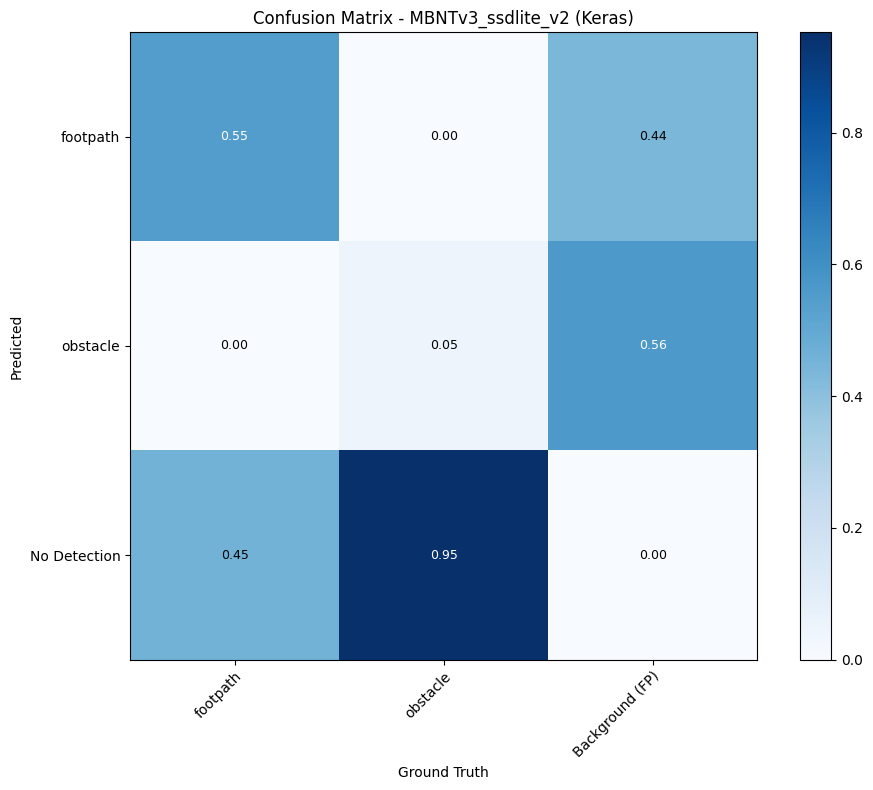

In [34]:
# Visualizar matriz de confusión del modelo Keras
fig_cm_keras = plot_confusion_matrix(
    cm=keras_results.confusion_matrix,
    class_names=CLASS_NAMES,
    title=f"Confusion Matrix - {MODEL_NAME} (Keras)",
    figsize=(10, 8),
    save_path=str(FIGURES_DIR   / f"{MODEL_NAME}_confusion_matrix_keras.png"),
)
plt.show()

🔍 Evaluando modelo TFLite INT8 en dataset de Test...
🔍 Evaluating model on 71 images...
   Loaded 71 images
   Processed 50/71 images
   Computing metrics...

📊 EVALUATION RESULTS

📈 Overall Metrics:
   mAP@50:     0.3624
   Precision:  0.7660
   Recall:     0.2250
   F1-Score:   0.3478

📦 Detection Counts:
   Ground Truth:     160
   Predictions:      47
   True Positives:   36
   False Positives:  11
   False Negatives:  124

📊 Per-Class Metrics:
   Class              AP@50     Prec   Recall       F1
   -----------------------------------------------
   footpath          0.6338   0.8611   0.5636   0.6813
   obstacle          0.0909   0.4545   0.0476   0.0862

📊 KERAS vs TFLITE COMPARISON

Metric                    Keras     TFLite       Diff
--------------------------------------------------
mAP@50                   0.4058     0.3624    +0.0435
Precision                0.6863     0.7660    -0.0797
Recall                   0.2188     0.2250    -0.0063
F1-Score                 0.3318  

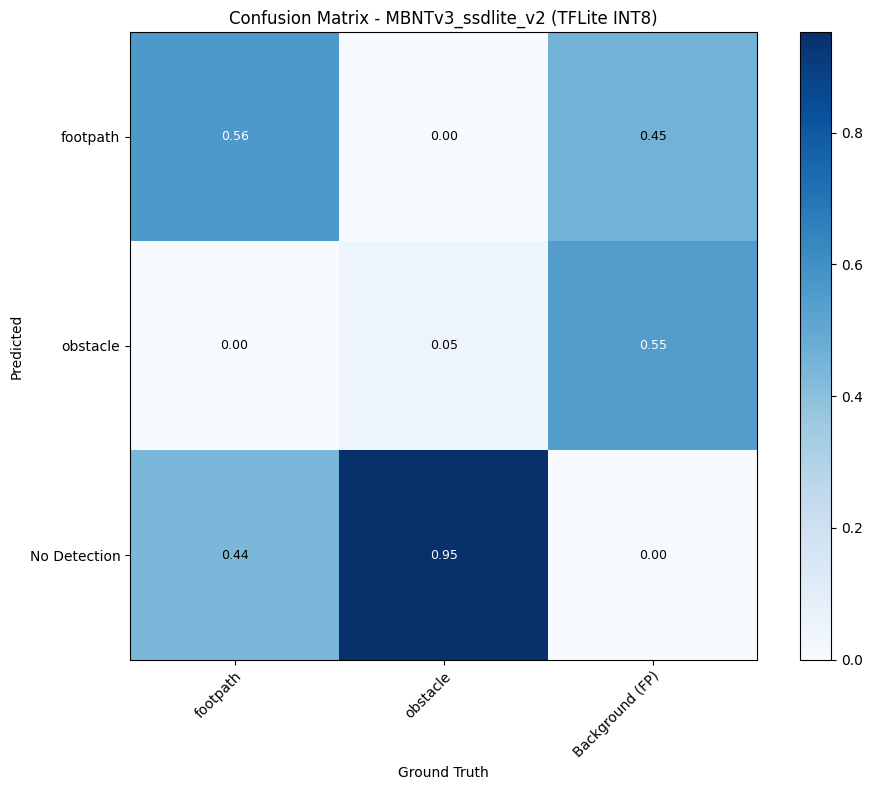

In [35]:
# Evaluar modelo TFLite INT8 (si existe)
int8_tflite_path = EXPORT_DIR / f"{MODEL_NAME}_int8.tflite"

if int8_tflite_path.exists():
    print("🔍 Evaluando modelo TFLite INT8 en dataset de Test...")
    
    # Cargar interpreter TFLite
    tflite_interpreter = tf.lite.Interpreter(model_path=str(int8_tflite_path))
    tflite_interpreter.allocate_tensors()
    
    tflite_results = evaluate_model_full(
        model=tflite_interpreter,
        test_data=test_data,
        anchors=anchors,
        num_classes=NUM_CLASSES,
        class_names=CLASS_NAMES,
        score_threshold=SCORE_THRESHOLD,
        nms_iou_threshold=0.5,
        eval_iou_threshold=0.5,
        cm_score_threshold=0.5,
        img_size=IMG_SIZE,
        batch_size=1,  # TFLite procesa de uno en uno
        is_tflite=True,
        verbose=True,
    )
    
    # Comparar Keras vs TFLite
    comparison = compare_keras_vs_tflite(keras_results, tflite_results, CLASS_NAMES)
    
    # Confusion matrix TFLite
    fig_cm_tflite = plot_confusion_matrix(
        cm=tflite_results.confusion_matrix,
        class_names=CLASS_NAMES,
        title=f"Confusion Matrix - {MODEL_NAME} (TFLite INT8)",
        figsize=(10, 8),
        save_path=str(FIGURES_DIR   / f"{MODEL_NAME}_confusion_matrix_tflite.png"),
    )
    plt.show()
else:
    print(f"⚠️ Modelo TFLite no encontrado: {int8_tflite_path}")
    print("   Ejecuta la exportación primero para comparar Keras vs TFLite")
    tflite_results = None

### Archivos Generados

| Tipo | Ruta |
|------|------|
| **Modelo Keras** | `models/final_export/{model_name}_final.keras` |
| **TFLite Float32** | `models/final_export/{model_name}_float32.tflite` |
| **TFLite Float16** | `models/final_export/{model_name}_float16.tflite` |
| **TFLite INT8** ⭐ | `models/final_export/{model_name}_int8.tflite` |
| **Logs** | `logs/{model_name}_phase{1,2}_history.csv` |
| **Figuras** | `reports/figures/{model_name}_*.png` |

## 💾 Guardar Experimento

Guardamos la configuración y resultados del experimento para poder comparar con otros experimentos.

In [36]:
# Crear configuración del experimento
experiment_config = ExperimentConfig(
    name=EXPERIMENT_NAME,
    description=EXPERIMENT_DESCRIPTION,
    backbone="MobileNetV3Small",
    minimalistic=True,
    num_anchors=NUM_ANCHORS_PER_CELL,
    num_classes=NUM_CLASSES,
    selected_classes=CLASS_NAMES,
    img_size=IMG_SIZE,
    augmentation_level=AUGMENTATION_LEVEL,
    phase1_epochs=PHASE1_EPOCHS,
    phase1_lr=PHASE1_LR,
    phase2_epochs=PHASE2_EPOCHS,
    phase2_lr=PHASE2_LR,
    batch_size=BATCH_SIZE,
    use_focal_loss=True,
    focal_alpha=FOCAL_ALPHA,
    focal_gamma=FOCAL_GAMMA,
    quantization="int8",   
    score_threshold = SCORE_THRESHOLD,
    feature_channels= FEATURE_CHANNELS
)

# Crear resultados del experimento
experiment_results = ExperimentResults(
    map50_keras=keras_results.map50,
    map50_tflite=tflite_results.map50 if tflite_results else 0.0,
    precision_keras=keras_results.precision,
    precision_tflite=tflite_results.precision if tflite_results else 0.0,
    recall_keras=keras_results.recall,
    recall_tflite=tflite_results.recall if tflite_results else 0.0,
    f1_keras=keras_results.f1_score,
    f1_tflite=tflite_results.f1_score if tflite_results else 0.0,
    ap_per_class_keras={CLASS_NAMES[k]: v for k, v in keras_results.ap_per_class.items()},
    ap_per_class_tflite={CLASS_NAMES[k]: v for k, v in tflite_results.ap_per_class.items()} if tflite_results else {},
    keras_model_path=str(EXPORT_DIR / f"{MODEL_NAME}_final.keras"),
    tflite_model_path=str(int8_tflite_path),
    tflite_model_size_kb=int8_tflite_path.stat().st_size / 1024 if int8_tflite_path.exists() else 0,
)

# Crear y guardar experimento completo
experiment = Experiment(config=experiment_config, results=experiment_results)
exp_path = save_experiment(experiment, base_dir=str(LOGS_DIR / "experiments"))

experiment_config.print_summary()
print(f"\n✅ Experimento guardado en: {exp_path}")

💾 Experiment saved to: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/experiments/mbntv3_ssdlite_v2_20260203_160006.json

🔬 EXPERIMENT: MBNTv3_ssdlite_v2
📝 Baseline con clases 'obstacle' y 'footpath', augmentation heavy, 45 épocas totales

🏗️ Model:
   Backbone: MobileNetV3Small (minimalistic=True)
   Anchors: 30
   Classes: 2 - ['footpath', 'obstacle']

📊 Data:
   Image size: 224x224
   Augmentation: heavy

🎯 Training:
   Phase 1: 20 epochs @ lr=0.0005
   Phase 2: 80 epochs @ lr=0.0001
   Batch size: 16
   Focal loss: True (α=0.25, γ=3.0)

📦 TFLite:
   Quantization: int8

✅ Experimento guardado en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/experiments/mbntv3_ssdlite_v2_20260203_160006.json


## 📈 Comparación de Experimentos

Carga y compara todos los experimentos guardados para análisis.

In [37]:
# Cargar todos los experimentos guardados
from src_mobilenet.utils_mobilenet_experiment import (
    load_all_experiments,
    compare_experiments,
    plot_experiments_comparison,
    create_experiment_summary_table,
)

all_experiments = load_all_experiments(str(LOGS_DIR / "experiments"))

if len(all_experiments) > 0:
    # Mostrar tabla de comparación
    df_comparison = compare_experiments(all_experiments, sort_by="mAP@50_keras", ascending=False)
    print("\n📊 Comparación de Experimentos:")
    display(df_comparison[["name", "mAP@50_keras", "mAP@50_tflite", "precision_keras", 
                           "recall_keras", "f1_keras", "tflite_size_kb"]])
    
    # Guardar tabla como CSV
    df_comparison.to_csv(REPORTS_DIR / "experiments_comparison.csv", index=False)
    print(f"\n💾 Tabla guardada en: {REPORTS_DIR / 'experiments_comparison.csv'}")
else:
    print("ℹ️ No hay experimentos guardados aún. Este será el primero.")

📂 Loaded 2 experiments from /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/experiments

📊 Comparación de Experimentos:


,name,mAP@50_keras,mAP@50_tflite,precision_keras,recall_keras,f1_keras,tflite_size_kb
0,MBNTv3_ssdlite_v1,0.567456,0.550925,0.267442,0.43125,0.330144,749.820312
1,MBNTv3_ssdlite_v2,0.405844,0.362374,0.686275,0.21875,0.331754,755.148438



💾 Tabla guardada en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/experiments_comparison.csv


💾 Comparison plot saved to: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/figures/MBNTv3_ssdlite_v2/experiments_comparison.png


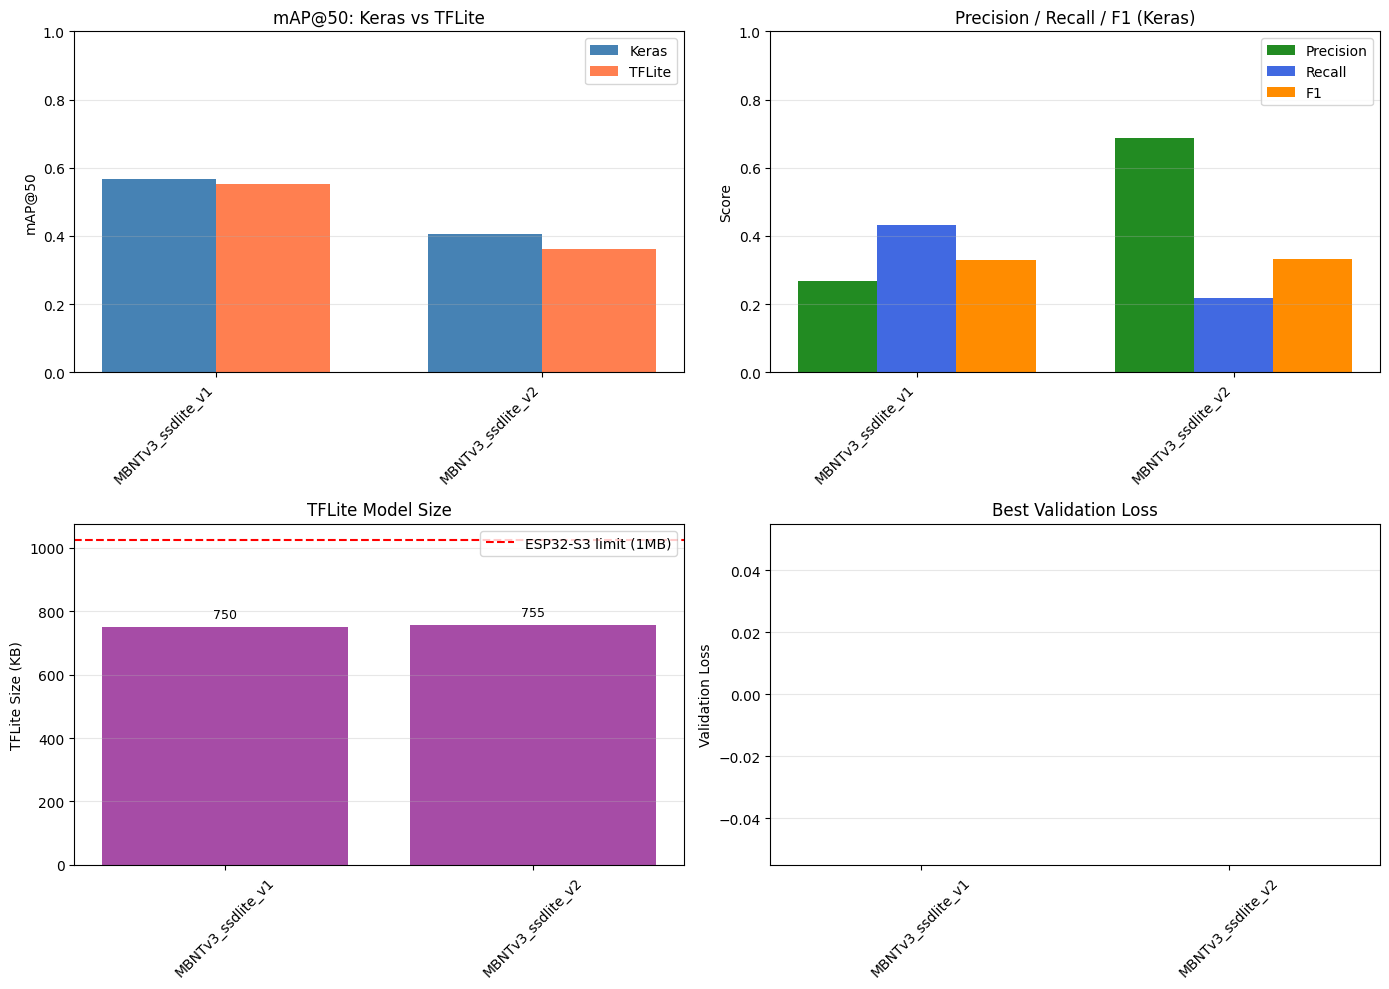

In [ ]:
# Gráfico de comparación visual (si hay más de 1 experimento)
if len(all_experiments) > 1:
    fig_comparison = plot_experiments_comparison(
        all_experiments,
        figsize=(14, 10),
        save_path=str(FIGURES_DIR   / "experiments_comparison.png"),
        title="Comparación de Experimentos - mAP@50 Keras vs TFLite",
        esp32_limit_mb=2.0,
    )
    plt.show()
else:
    print("ℹ️ Ejecuta más experimentos cambiando EXPERIMENT_NAME y configuración")
    print("   Luego vuelve a ejecutar esta sección para ver la comparación gráfica")